In [1]:
import sys
import gmsh
import pyvista as pv
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from mpi4py import MPI
from dolfinx import fem, io, plot
from dolfinx.fem import Constant, Function, form, assemble_scalar
from dolfinx.fem.petsc import LinearProblem, create_matrix, create_vector, assemble_matrix, assemble_vector, apply_lifting, set_bc
from basix.ufl import element, mixed_element
from petsc4py import PETSc

from ufl import (FacetNormal, Identity, TestFunction, TrialFunction,
                 div, dot, ds, dx, inner, lhs, nabla_grad, grad, rhs, sym, sqrt,
                 TestFunctions, TrialFunctions, CellDiameter)


In [2]:
meshfile = Path("/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh").resolve()

In [3]:
# Future task: into a helper function
gmsh.initialize()
gmsh.option.setNumber("General.Terminal", 1)
gmsh.open(str(meshfile))

phy_groups = gmsh.model.getPhysicalGroups()
name_to_id = {gmsh.model.getPhysicalName(dim, tag): tag for (dim, tag) in phy_groups}
gmsh.finalize()

print(name_to_id)

Info    : Reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'...
Info    : 53 entities
Info    : 1600 nodes
Info    : 3208 elements
Info    : Done reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'
{'Inflow': 2, 'Outflow': 3, 'Walls': 4, 'Obstacles': 5, 'Volume': 1}


In [4]:
domain, cell_tags, facet_tags = io.gmshio.read_from_msh(meshfile, MPI.COMM_WORLD, gdim=2)

coords = domain.geometry.x
x_lim, y_lim = np.max(coords[:, 0]), np.max(coords[:, 1])

# Function spaces for v and p
elem_u = element("Lagrange", domain.basix_cell(), 2, shape=(2,))
elem_p = element("Lagrange", domain.basix_cell(), 1)

V = fem.functionspace(domain, elem_u)
Q = fem.functionspace(domain, elem_p)
fdim = domain.topology.dim - 1
gdim = 2

topology, cell_type, geom = plot.vtk_mesh(V) 
grid = pv.UnstructuredGrid(topology, cell_type, geom)

# Temporal parameters
t = 0.0
T = 3.0  # Final time
dt = 1 / 1000  # Time step size
num_steps = int(T / dt)
time_steps = np.arange(t, T, dt)

k = Constant(domain, PETSc.ScalarType(dt))
mu = Constant(domain, PETSc.ScalarType(0.001))  # Dynamic viscosity
rho = Constant(domain, PETSc.ScalarType(1))  # Density

Info    : Reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'...
Info    : 53 entities
Info    : 1600 nodes
Info    : 3208 elements
Info    : Done reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'


In [5]:
# No slip conditions
u_nonslip = np.array((0,) * domain.geometry.dim, dtype=PETSc.ScalarType)
no_slip_tags = ["Walls", "Obstacles"]

mesh_ids = np.concatenate([facet_tags.find(name_to_id[name]) for name in no_slip_tags])
dofs = fem.locate_dofs_topological(V, fdim, mesh_ids)
no_slip_bc = fem.dirichletbc(u_nonslip, dofs, V)

# Inflow boundary
inflow_facets = facet_tags.find(name_to_id["Inflow"])
inflow_dofs = fem.locate_dofs_topological(V, fdim, inflow_facets)
t_ramp_up = 2.0 # Time to apply the boundary condition smoothly
v_max = 1.0 # Maximum velocity in the middle of the inlet

if t_ramp_up > T:
    raise ValueError("Ramp up time for inflow profile must be shorter than total duration.")

class ParabolicInflow:
    def __init__(self, t):
        self.t = t

    def __call__(self, x):
        scale = min(self.t / t_ramp_up, v_max)  # 2 s ramp-up
        v_x = scale * 4.0*(x[1]/y_lim)*(1.0 - x[1]/y_lim)
        v_y = np.zeros_like(x[1])
        return np.stack((v_x, v_y))

u_inlet = Function(V)
inlet_velocity = ParabolicInflow(t)
u_inlet.interpolate(inlet_velocity)

bc_in = fem.dirichletbc(u_inlet, inflow_dofs)

# Outflow
dofs_out = fem.locate_dofs_topological(Q, fdim, facet_tags.find(name_to_id["Outflow"]))
bc_out = fem.dirichletbc(PETSc.ScalarType(0), dofs_out, Q)

# bcs summary
velocity_bcs = [bc_in, no_slip_bc]
pressure_bcs = [bc_out]

print("V dofs total:", V.dofmap.index_map.size_global * V.dofmap.index_map_bs)
print("no-slip dofs:", len(dofs))               # aus deinem no_slip_bc
print("inflow dofs:", len(inflow_dofs))

V dofs total: 12328
no-slip dofs: 394
inflow dofs: 53


In [6]:
# Variational formulation
u = TrialFunction(V)
v = TestFunction(V)
u_ = Function(V, name="u")
u_s = Function(V, name="u_tentative")
u_n = Function(V)
u_n1 = Function(V)
p = TrialFunction(Q)
q = TestFunction(Q)
p_ = Function(Q, name="p")
phi = Function(Q, name="phi")

f = Constant(domain, PETSc.ScalarType((0, 0)))
F1 = rho / k * dot(u - u_n, v) * dx
F1 += inner(dot(1.5 * u_n - 0.5 * u_n1, 0.5 * nabla_grad(u + u_n)), v) * dx
F1 += 0.5 * mu * inner(grad(u + u_n), grad(v)) * dx - dot(p_, div(v)) * dx
F1 += dot(f, v) * dx
a1 = form(lhs(F1))
L1 = form(rhs(F1))
A1 = create_matrix(a1)
b1 = create_vector(L1)

a2 = form(dot(grad(p), grad(q)) * dx)
L2 = form(-rho / k * dot(div(u_s), q) * dx)
A2 = assemble_matrix(a2, bcs=pressure_bcs)
A2.assemble()
b2 = create_vector(L2)

a3 = form(rho * dot(u, v) * dx)
L3 = form(rho * dot(u_s, v) * dx - k * dot(nabla_grad(phi), v) * dx)
A3 = assemble_matrix(a3)
A3.assemble()
b3 = create_vector(L3)

In [7]:
# Solver for step 1
solver1 = PETSc.KSP().create(domain.comm)
solver1.setOperators(A1)
solver1.setType(PETSc.KSP.Type.BCGS)
pc1 = solver1.getPC()
pc1.setType(PETSc.PC.Type.JACOBI)

# Solver for step 2
solver2 = PETSc.KSP().create(domain.comm)
solver2.setOperators(A2)
solver2.setType(PETSc.KSP.Type.MINRES)
pc2 = solver2.getPC()
pc2.setType(PETSc.PC.Type.HYPRE)
pc2.setHYPREType("boomeramg")

# Solver for step 3
solver3 = PETSc.KSP().create(domain.comm)
solver3.setOperators(A3)
solver3.setType(PETSc.KSP.Type.CG)
pc3 = solver3.getPC()
pc3.setType(PETSc.PC.Type.SOR)

Reached max iterations. Final L2 error = 1.388e-07


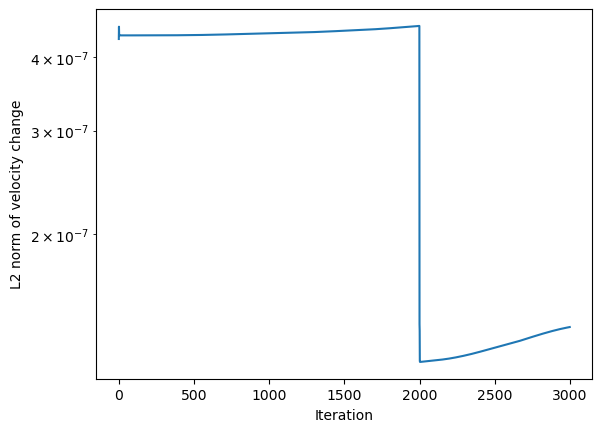

In [8]:
# --- Convergence monitoring ---
num_dofs = V.dofmap.index_map.size_global * V.dofmap.index_map_bs
u_diff = Function(V)
l2_norm_squared = form(inner(u_diff, u_diff) * dx)

l2_errors = []
it_conv = None
tol_stationary = 1e-6

for i in range(num_steps):
    t += dt

    # Update inlet during ramp-up
    inlet_velocity.t = t
    u_inlet.interpolate(inlet_velocity)

    vals = u_inlet.x.array.reshape(-1, domain.geometry.dim)
    speeds = np.linalg.norm(vals, axis=1)

    # ---- Step 1: tentative velocity ----
    A1.zeroEntries()
    assemble_matrix(A1, a1, bcs=velocity_bcs)
    A1.assemble()
    with b1.localForm() as loc:
        loc.set(0)
    assemble_vector(b1, L1)
    apply_lifting(b1, [a1], [velocity_bcs])
    b1.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES,
                mode=PETSc.ScatterMode.REVERSE)
    set_bc(b1, velocity_bcs)
    solver1.solve(b1, u_s.x.petsc_vec)
    u_s.x.scatter_forward()

    # ---- Step 2: pressure correction ----
    with b2.localForm() as loc:
        loc.set(0)
    assemble_vector(b2, L2)
    apply_lifting(b2, [a2], [pressure_bcs])
    b2.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)
    set_bc(b2, pressure_bcs)
    solver2.solve(b2, phi.x.petsc_vec)
    phi.x.scatter_forward()

    p_.x.petsc_vec.axpy(1, phi.x.petsc_vec)
    p_.x.scatter_forward()

    # ---- Step 3: velocity correction ----
    with b3.localForm() as loc:
        loc.set(0)
    assemble_vector(b3, L3)
    b3.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)
    solver3.solve(b3, u_.x.petsc_vec)
    u_.x.scatter_forward()

    # ---- Check convergence ----
    u_diff.x.array[:] = u_.x.array - u_n.x.array
    l2_err = np.sqrt(assemble_scalar(l2_norm_squared)) / num_dofs
    l2_errors.append(l2_err)

    # if t > t_ramp_up:
    #     if l2_err < tol_stationary:
    #         it_conv = i
    #         print(f"Converged at iteration {i+1}, t={t:.3f}s")
    #         print(f"L2 delta(u) = {l2_err:.3e}")
    #         break

    # Update "previous" states
    with (
        u_.x.petsc_vec.localForm() as loc_,
        u_n.x.petsc_vec.localForm() as loc_n,
        u_n1.x.petsc_vec.localForm() as loc_n1,
    ):
        loc_n.copy(loc_n1)
        loc_.copy(loc_n)

if it_conv is None:
    print(f"Reached max iterations. Final L2 error = {l2_errors[-1]:.3e}")

plt.semilogy(l2_errors)
plt.xlabel("Iteration")
plt.ylabel("L2 norm of velocity change")
plt.show()

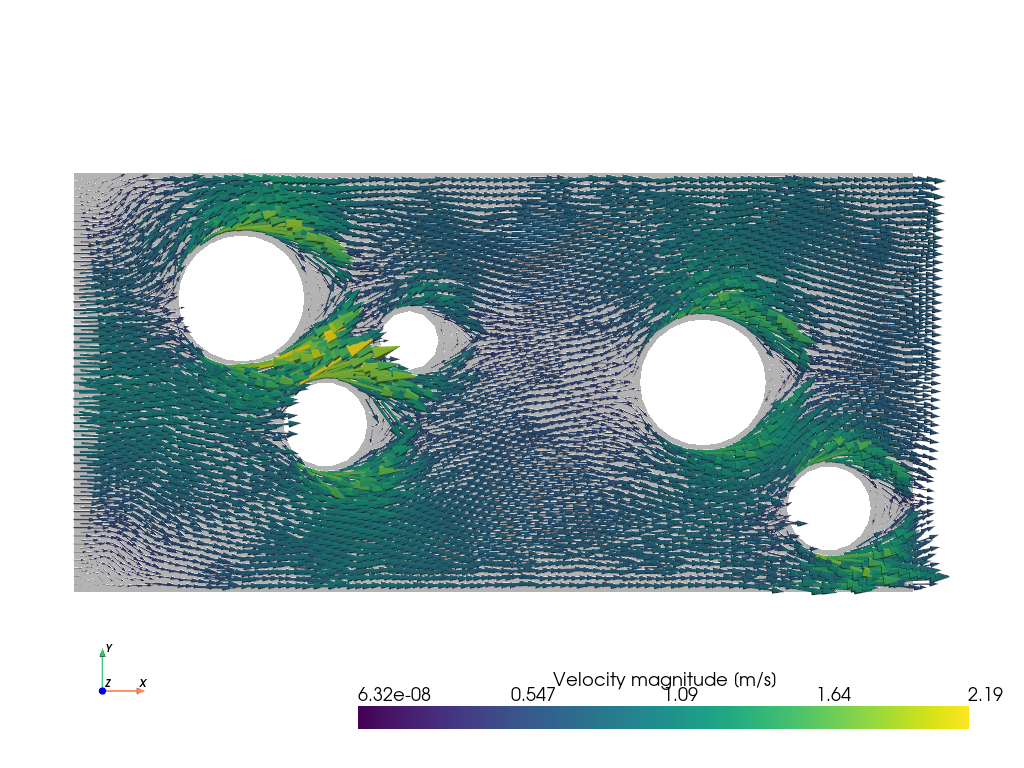

In [9]:
# Visualize
wind2d = u_n1.x.array.reshape(-1, 2)
wind3d = np.hstack((wind2d, np.zeros((wind2d.shape[0], 1))))
grid.point_data["wind_vectors"] = wind3d
wind_plot_indices = np.arange(0, grid.n_points, 1)
subset = grid.extract_points(wind_plot_indices, include_cells=False)
glyphs = subset.glyph(orient="wind_vectors", scale="wind_vectors", factor=1.0)

pl = pv.Plotter()
pl.add_mesh(glyphs, scalar_bar_args={"title": "Velocity magnitude [m/s]"})
pl.add_mesh(grid, color='k', opacity=0.3)
pl.view_xy()
pl.zoom_camera(1.3)
pl.show_axes()
pl.show()

In [ ]:
# Save file
import adios4dolfinx

wind_file = Path("/home/dominik/git/dispersion_sim/wind_data/airflow_ipcs.bp")
adios4dolfinx.write_mesh(wind_file, domain)
adios4dolfinx.write_meshtags(wind_file, domain, facet_tags, meshtag_name="facet_tags")
adios4dolfinx.write_function(wind_file, u_n1, name="velocity_H2")

In [11]:
# from dolfinx.io import XDMFFile
# from mpi4py import MPI

# elem_u_vis = element("Lagrange", domain.basix_cell(), 1, shape=(2,))
# V_vis = fem.functionspace(domain, elem_u_vis)
# u_vis = fem.Function(V_vis)
# u_vis.interpolate(u_n1)

# with XDMFFile(MPI.COMM_WORLD, "solution.xdmf", "w") as xdmf:
#     xdmf.write_mesh(domain)
#     xdmf.write_function(u_vis, 0.0)   # velocity
#     #xdmf.write_function(p_,    0.0)   # pressure